**1. CONVOLUTIONAL AUTOENCODERS TRAINING**

In [19]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

NOME_PROGETTO = "floods"
project = dh.get_project(NOME_PROGETTO)
print(f"Progetto: {project.name}")

Progetto: floods


**SETUP PARAMETERS**

In [20]:
# Parametri Job
job_name = "train_opt_1D_v1"                                    
dataset = "Standard" 
epochs = 200
train_sar = False
train_opt = True                                           # Test, Standard, Anomalies*
#handler = pretrain_encoders                                         

parametri = {
    "epochs": epochs, 
    "batch_size": 16, 
    "lr": 1e-4, 
    "weight_decay": 1e-4,      
    "patch_size": 256, 
    "n_images1": 4, "n_channels1": 2,                       # sar
    "n_images2": 4, "n_channels2": 10,                      # opt
    "output_dim": 512,                                      # dimensione spazio latente                                                     
    "mamba": False, 
    "workers": 0,
    "job_name": job_name,
    "dataset": dataset,
    "train_sar": train_sar,                                  # train sar encoder
    "train_opt": train_opt,                                  # train opt encoder
    "patience": 10,                                    
    "min_delta": 1e-4,
    "resume": False,
    "time_debug": False                                     # time_debug = True solo per debug, = False per training
}

print(f"PARAMETRI: {parametri}")

# volume -> circa 400 GB dataset Standard
volumi = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "600Gi"}   
    }
]

PARAMETRI: {'epochs': 200, 'batch_size': 16, 'lr': 0.0001, 'weight_decay': 0.0001, 'patch_size': 256, 'n_images1': 4, 'n_channels1': 2, 'n_images2': 4, 'n_channels2': 10, 'output_dim': 512, 'mamba': False, 'workers': 0, 'job_name': 'train_opt_1D_v1', 'dataset': 'Standard', 'train_sar': False, 'train_opt': True, 'patience': 10, 'min_delta': 0.0001, 'resume': False, 'time_debug': False}


**BUILD ENVIRONMENT**

In [21]:
encoders_train_func = project.new_function(
    name= f'encoders-Floods_{job_name}_{dataset}_{epochs}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_autoencoders_1D", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2"]
)

# .run("build") -> scarica immagine, installa requirements, copia intera cartella code_src, crea immagine docker

build = encoders_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-09-19 16:59:08,198 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16:59:13,204 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16:59:18,256 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16:59:23,264 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16:59:28,273 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16:59:33,281 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16:59:38,290 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run b2af28a90aa142d8b67dd6ccb51947e0 to finish...
2026-09-19 16

BUILD: COMPLETED


**TRAINING**

In [ ]:
# action job = avvia container, esegue script, libera risorse

run_train_encoders = encoders_train_func.run(
    action="job", 
    parameters=parametri, 
    volumes=volumi, 
    profile="1xv100",                                       # 1x = 1 gpu
    # local_execution= True,                                
    wait=True
)

print(f"Run train_encoders avviato: {run_train_encoders.id}")
print(run_train_encoders.status.state)
print(run_train_encoders.status.message)

2026-09-19 16:59:58,436 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17:00:03,442 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17:00:08,450 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17:00:13,459 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17:00:18,468 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17:00:23,476 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17:00:28,588 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 8e1c88404bca46c790930b852cf4e932 to finish...
2026-09-19 17

**PLOTS**

In [ ]:
if train_sar:
    # salvataggio log
    path_s1 = project.get_artifact(f"metrics-s1_{job_name}_{dataset}_{epochs}").download(overwrite=True)
    df_s1 = pd.read_csv(path_s1)

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(df_s1['epoch'], df_s1['train_loss'], color='blue', label='Train Loss')
    plt.title(f'Training CAE SAR - {job_name}_{dataset}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("train sar non eseguito")

train sar non eseguito


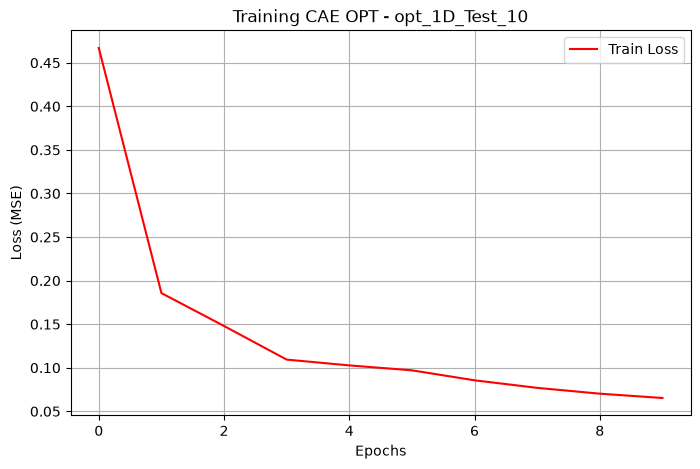

In [ ]:
if train_opt:
    # salvataggio log
    path_s2 = project.get_artifact(f"metrics-s2_{job_name}_{dataset}_{epochs}").download(overwrite=True)
    df_s2 = pd.read_csv(path_s2)

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(df_s2['epoch'], df_s2['train_loss'], color='red', label='Train Loss')
    plt.title(f'Training CAE OPT - {job_name}_{dataset}_{epochs}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("train opt non eseguito")